# Conversion Drivers Analysis

This notebook explores customer and campaign attributes that influence
the likelihood of conversion.

The goal is to identify high-performing segments that can be targeted
more effectively in future campaigns.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.style.use("default")

In [2]:
df = pd.read_csv("bank_marketing_cleaned.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,y_binary
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no,0
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no,0
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no,0
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no,0


In [3]:
# Conversion rate by jobs

job_conv = (
    df.groupby("job")["y_binary"]
    .mean()
    .sort_values(ascending=False)
    * 100
)
job_conv

job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: y_binary, dtype: float64

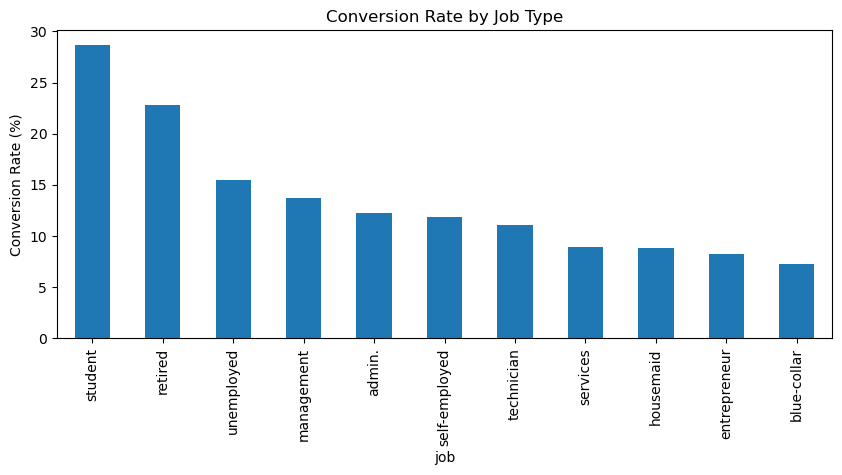

In [4]:
# Plot: conversion rate by job type
job_conv.plot(kind="bar", figsize=(10,4))
plt.title("Conversion Rate by Job Type")
plt.ylabel("Conversion Rate (%)")
plt.show()

Certain job categories show consistently higher conversion rates.

This insight can be used to prioritize customer segments that are
more receptive to term deposit offers.

In [5]:
# Create age buckets
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18–30", "31–40", "41–50", "51–60", "60+"]
)

age_conv = (
    df.groupby("age_group")["y_binary"]
    .mean()
    * 100
)

age_conv

age_group
18–30    16.215446
31–40    10.244813
41–50     9.066643
51–60    10.053304
60+      42.255892
Name: y_binary, dtype: float64

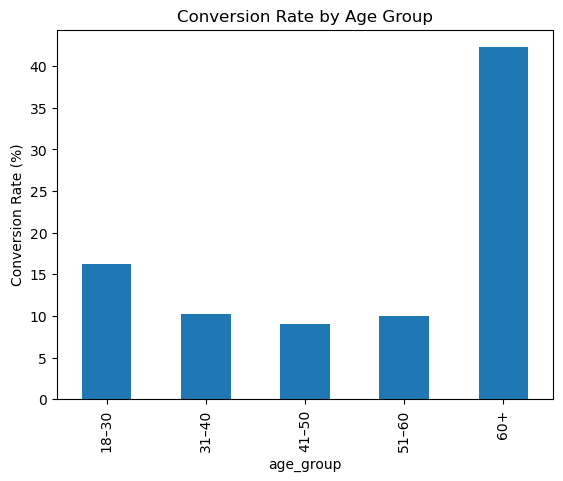

In [6]:
# Plot: conversion rate by age group
age_conv.plot(kind="bar")
plt.title("Conversion Rate by Age Group")
plt.ylabel("Conversion Rate (%)")
plt.show()

Previous campaign outcomes provide strong signals about customer intent.

Customers with a successful previous interaction are more likely to convert again.

In [7]:
poutcome_conv = (
    df.groupby("poutcome")["y_binary"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

poutcome_conv

poutcome
success    64.725347
other      16.684783
failure    12.609671
Name: y_binary, dtype: float64

### Key Conversion Drivers Identified

- Contact method
- Campaign frequency
- Job category
- Age group
- Previous campaign outcome

These factors should guide campaign targeting and personalization strategies.